# Exercise - Computer Vision

In [88]:
!pip install torchmetrics

In [104]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm
from torchmetrics.classification import MulticlassConfusionMatrix
from pathlib import Path

## Dataset Creation

In [90]:
# Dataset
train_data = torchvision.datasets.FashionMNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    target_transform = None,
    download = True
)

test_data = torchvision.datasets.FashionMNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    target_transform = None,
    download = True
)




Shape of the overall data:  torch.Size([60000, 28, 28])
Number of data:  60000
Size of an image:  torch.Size([1, 28, 28])
Value in the image: 0.0 to 1.0
Classes in the dataset:  ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Text(0.5, 1.0, '9 | Ankle boot')

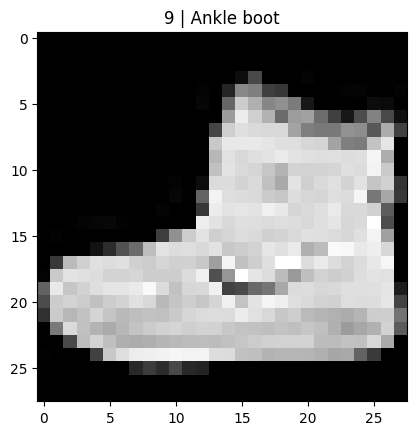

In [91]:
## Visualize Dataset

image, label = train_data[0]

print('Shape of the overall data: ', train_data.data.shape)
print('Number of data: ', len(train_data))
print('Size of an image: ', image.shape)
print(f'Value in the image: {torch.min(image)} to {torch.max(image)}')
print('Classes in the dataset: ', train_data.classes)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'{label} | {train_data.classes[label]}')


## Dataloader creation

In [92]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size = BATCH_SIZE,
    shuffle = True,
)

test_dataloader = DataLoader(
    test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)

## Visualizing the dataloader

In [93]:
images, labels = next(iter(train_dataloader))

print('Shape of a batch of images: ', images.shape)
print('Shape of a batch of labels: ', labels.shape)

Shape of a batch of images:  torch.Size([32, 1, 28, 28])
Shape of a batch of labels:  torch.Size([32])


## Build a model

In [94]:
class TinyVGG(nn.Module):
    def __init__(
            self, 
            in_channels: int, 
            hidden_units: int,
            out_channels: int,
            in_img_size: int
            ):
        super().__init__()
        self.conv_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2
            )
        ) # 14 x 14

        self.conv_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2
            )
        ) # 7 x 7

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units*int(in_img_size/4)*int(in_img_size/4),
                out_features=1024
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=1024,
                out_features=512
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=512,
                out_features=256
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=256,
                out_features=out_channels
            )
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.conv_2(self.conv_1(x)))


## Training and Testing Steps 

In [95]:
def train_step(
        model: torch.nn.Module,
        data: torch.Tensor,
        labels: torch.Tensor,
        loss_fn: nn.Module,
        acc_fn: torchmetrics.classification,
        num_classes: int,
        optimizer: torch.optim
) -> tuple[float, float]:

    model.train()
    y_preds = model(data).squeeze()
    loss = loss_fn(y_preds, torch.nn.functional.one_hot(labels, num_classes=num_classes).to(torch.float32))
    acc = acc_fn(torch.argmax(y_preds, dim=1), labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), acc.item()


def test_step(
        model: torch.nn.Module,
        data: torch.Tensor,
        labels: torch.Tensor,
        loss_fn: nn.Module,
        acc_fn: torchmetrics.classification,
        num_classes: int,
) -> tuple[float, float]:

    model.eval()
    with torch.inference_mode():
        y_preds = model(data).squeeze()
        loss = loss_fn(y_preds, torch.nn.functional.one_hot(labels, num_classes=num_classes).to(torch.float32))
        acc = acc_fn(torch.argmax(y_preds, dim=1), labels)

    return loss.item(), acc.item()

    
    



## Training and Testing Loop

In [96]:
# Hyperparameter
MANUAL_SEED = 42
NUM_CLASSES = len(train_data.classes)
LEARNING_RATE = 1e-3
EPOCHS = 3
device = 'cuda' if torch.cuda.is_available() else 'cpu'


# define models and utils
torch.manual_seed(MANUAL_SEED)
torch.cuda.manual_seed(MANUAL_SEED)

model_0 = TinyVGG(
    in_channels=1,
    hidden_units=32,
    out_channels=NUM_CLASSES,
    in_img_size=train_data.data[0].shape[-1]
).to(device)

optimizer = torch.optim.Adam(
    model_0.parameters(),
    LEARNING_RATE
)

loss_fn = nn.CrossEntropyLoss()

acc_fn = MulticlassAccuracy(
    num_classes = NUM_CLASSES,
    average = 'micro'
).to(device)

# Loop
epochs_plt = []
train_loss_plt = []
test_loss_plt = []
train_acc_plt = []
test_acc_plt = []

for epoch in range(EPOCHS):

    train_loss_ep = 0
    train_acc_ep = 0
    test_loss_ep = 0
    test_acc_ep = 0

    for batch_idx, (X, y) in tqdm(enumerate(train_dataloader)):
        train_loss, train_acc = train_step(
            model = model_0,
            data = X.to(device),
            labels = y.to(device),
            loss_fn = loss_fn,
            acc_fn = acc_fn,
            num_classes = NUM_CLASSES,
            optimizer = optimizer
        )
        train_loss_ep += train_loss
        train_acc_ep += train_acc

    for batch_idx, (X, y) in tqdm(enumerate(test_dataloader)):
        test_loss, test_acc = test_step(
            model = model_0,
            data = X.to(device),
            labels = y.to(device),
            loss_fn = loss_fn,
            acc_fn = acc_fn,
            num_classes = NUM_CLASSES,
        )
        test_loss_ep += test_loss
        test_acc_ep += test_acc

    
    num_train_batches = len(train_dataloader)
    num_test_batches = len(test_dataloader)
    train_loss_ep /= num_train_batches
    train_acc_ep /= num_train_batches
    test_loss_ep /= num_test_batches
    test_acc_ep /= num_test_batches

    print('Epoch: ', epoch)
    print(f'Training Loss: {train_loss_ep:.4f} | Training Acc: {train_acc_ep:.2f}')
    print(f'Testing Loss: {test_loss_ep:.4f} | Testing Acc: {test_acc_ep:.2f}')


    epochs_plt.append(epoch)
    train_loss_plt.append(train_loss_ep)
    test_loss_plt.append(test_loss_ep)
    train_acc_plt.append(train_acc_ep)
    test_acc_plt.append(test_acc_ep)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Epoch:  0
Training Loss: 0.4765 | Training Acc: 0.82
Testing Loss: 0.3806 | Testing Acc: 0.87


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Epoch:  1
Training Loss: 0.2720 | Training Acc: 0.90
Testing Loss: 0.2546 | Testing Acc: 0.91


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Epoch:  2
Training Loss: 0.2244 | Training Acc: 0.92
Testing Loss: 0.2479 | Testing Acc: 0.91


## Save and Load Models

In [105]:
# Save a model
save_folder = Path('models')
save_folder.mkdir(parents=True, exist_ok=True)
save_path = save_folder / 'model_0.pt'
torch.save(model_0.state_dict(), save_path)

In [106]:
## Load a model
loaded_model = TinyVGG(
    in_channels = 1,
    hidden_units = 32,
    out_channels = NUM_CLASSES,
    in_img_size = 28
).to(device)

loaded_model.load_state_dict(torch.load(save_path, weights_only=True))

<All keys matched successfully>

## Confusion Matrix

0it [00:00, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

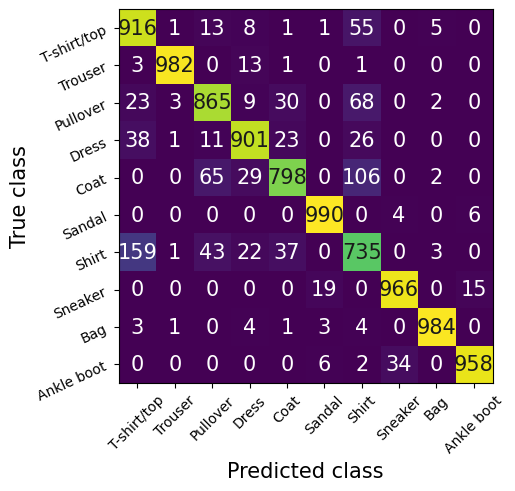

In [107]:
loaded_model.eval()
y_total_preds = []
y_labels = []
with torch.inference_mode():
    for batch_idx, (X, y) in tqdm(enumerate(test_dataloader)):
        X, y = X.to(device), y.to(device)
        y_preds = loaded_model(X)
        y_preds_labels = torch.argmax(y_preds, dim=1)

        y_labels.append(y)
        y_total_preds.append(y_preds_labels)

y_total_preds = [ item for sublist in y_total_preds for item in sublist ]
y_labels = [ item for sublist in y_labels for item in sublist ]

cm = MulticlassConfusionMatrix(num_classes=NUM_CLASSES)
cm.update(torch.tensor(y_total_preds), torch.tensor(y_labels))
cm.plot(labels=train_data.classes)